In [20]:
#This notebook creates spatial distribution maps of energy poverty
import numpy as np
import pandas as pd

df= pd.read_parquet("PAKISTAN/DATA/4.PK_MASTER_DATASET.parquet", engine="pyarrow")


In [21]:
sorted(df["hv024RegionDivision"].dropna().unique())

[1, 2, 3, 4, 5, 6, 7, 8]

In [22]:
region_lookup = {
1: "Punjab",
2: "Sindh",
3: "KPK",
4: "Balochistan",
5: "GB",
6: "ICT",
7: "AJK",
8: "FATA"
}

df["region_name"] = df["hv024RegionDivision"].map(region_lookup)

#df[["hv024RegionDivision","region_name"]].head(20)

In [23]:
region_headcount = (
    df.groupby("region_name")
      .apply(lambda x: (x["EnergyPoor"] * x["weight"]).sum() / x["weight"].sum() * 100)
      .reset_index(name="headcount_pct")
)

region_headcount["headcount_pct"] = region_headcount["headcount_pct"].round(0)

region_headcount

C:\Users\ayeei\AppData\Local\Temp\ipykernel_35112\276070815.py:3: RuntimeWarning: invalid value encountered in scalar divide
  .apply(lambda x: (x["EnergyPoor"] * x["weight"]).sum() / x["weight"].sum() * 100)
C:\Users\ayeei\AppData\Local\Temp\ipykernel_35112\276070815.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["EnergyPoor"] * x["weight"]).sum() / x["weight"].sum() * 100)


,region_name,headcount_pct
0,AJK,NaN
1,Balochistan,55.0
2,FATA,91.0
3,GB,NaN
4,ICT,9.0
5,KPK,58.0
6,Punjab,37.0
7,Sindh,45.0


In [24]:
import geopandas as gpd

pk_map = gpd.read_file(
     r"PAKISTAN/SHPS/sdr_subnational_boundaries.shp"
)

pk_map.head()

,ISO,FIPS,DHSCC,SVYTYPE,SVYYEAR,CNTRYNAMEE,CNTRYNAMEF,CNTRYNAMES,DHSREGEN,DHSREGFR,...,REGNAME,OTHREGVAR,OTHREGCO,OTHREGNA,LEVELCO,LEVELNA,REPALLIND,REGNOTES,SVYNOTES,geometry
0,PK,PK,PK,DHS,2017.0,Pakistan,None,None,"Azad, Jammu and Kashmir",None,...,AJK,NULL,9999.0,NULL,Admin1,Provinces,yes,None,Survey is representative to 8 Regionss as Admi...,"POLYGON ((74.6493 35.13991, 74.66885 35.12403,..."
1,PK,PK,PK,DHS,2017.0,Pakistan,None,None,Balochistan,None,...,Balochistan,NULL,9999.0,NULL,Admin1,Provinces,yes,None,Survey is representative to 8 Regionss as Admi...,"MULTIPOLYGON (((66.61289 24.89664, 66.61291 24..."
2,PK,PK,PK,DHS,2017.0,Pakistan,None,None,Federally Administered Tribal Areas,None,...,FATA,NULL,9999.0,NULL,Admin1,Provinces,yes,None,Survey is representative to 8 Regionss as Admi...,"POLYGON ((71.55079 34.95385, 71.55289 34.95064..."
3,PK,PK,PK,DHS,2017.0,Pakistan,None,None,Islamabad (ICT),None,...,ICT,NULL,9999.0,NULL,Admin1,Provinces,yes,Full region name is Islamabad Capital Territory,Survey is representative to 8 Regionss as Admi...,"POLYGON ((73.37941 33.83376, 73.37756 33.78699..."
4,PK,PK,PK,DHS,2017.0,Pakistan,None,None,Gilgit Baltistan,None,...,GB,NULL,9999.0,NULL,Admin1,Provinces,yes,None,Survey is representative to 8 Regionss as Admi...,"POLYGON ((74.70041 37.08105, 74.70689 37.07327..."


In [25]:
pk_map.columns

Index(['ISO', 'FIPS', 'DHSCC', 'SVYTYPE', 'SVYYEAR', 'CNTRYNAMEE',
       'CNTRYNAMEF', 'CNTRYNAMES', 'DHSREGEN', 'DHSREGFR', 'DHSREGSP', 'SVYID',
       'REG_ID', 'Svy_Map', 'MULTLEVEL', 'LEVELRNK', 'REGVAR', 'REGCODE',
       'REGNAME', 'OTHREGVAR', 'OTHREGCO', 'OTHREGNA', 'LEVELCO', 'LEVELNA',
       'REPALLIND', 'REGNOTES', 'SVYNOTES', 'geometry'],
      dtype='object')

In [26]:
sorted(pk_map["REGNAME"].dropna().unique())

['AJK', 'Balochistan', 'FATA', 'GB', 'ICT', 'KPK', 'Punjab', 'Sindh']

In [27]:
pk_gdf = pk_map.merge(
    region_headcount,
    left_on="REGNAME",
    right_on="region_name",
    how="left"
)

pk_gdf[["REGNAME", "headcount_pct"]]

,REGNAME,headcount_pct
0,AJK,NaN
1,Balochistan,55.0
2,FATA,91.0
3,ICT,9.0
4,GB,NaN
5,KPK,58.0
6,Punjab,37.0
7,Sindh,45.0


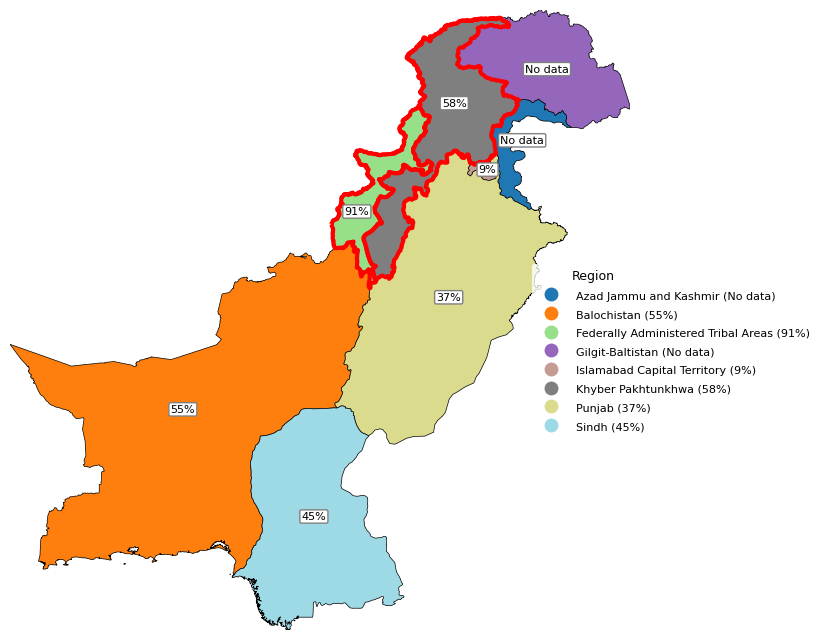

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

fig, ax = plt.subplots(figsize=(8, 9))

pk_gdf.plot(
    column="REGNAME",
    cmap="tab20",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey"}
)

q75 = pk_gdf["headcount_pct"].quantile(0.75)
top_quartile = pk_gdf[pk_gdf["headcount_pct"] >= q75]

top_quartile.boundary.plot(
    ax=ax,
    edgecolor="red",
    linewidth=3
)

legend = ax.get_legend()
legend.set_title("Region")

legend_labels = {
    "AJK": "Azad Jammu and Kashmir",
    "GB": "Gilgit-Baltistan",
    "ICT": "Islamabad Capital Territory",
    "KPK": "Khyber Pakhtunkhwa",
    "FATA": "Federally Administered Tribal Areas",
    "Punjab": "Punjab",
    "Sindh": "Sindh",
    "Balochistan": "Balochistan"
}

# create region -> headcount lookup
headcount_lookup = dict(zip(pk_gdf["REGNAME"], pk_gdf["headcount_pct"]))

# update legend text to show full region name + percentage
for text in legend.get_texts():
    short = text.get_text()
    full_name = legend_labels.get(short, short)
    headcount = headcount_lookup.get(short)

    if pd.notna(headcount):
        #text.set_text(f"{full_name}, {int(headcount)}%")
        text.set_text(f"{full_name} ({int(headcount)}%)")
    else:
        #text.set_text(f"{full_name}, No data")
        text.set_text(f"{full_name} (No data)")

# remove extra white space
xmin, ymin, xmax, ymax = pk_gdf.total_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.margins(0)

label_offsets = {
    "KPK": (0, 1),          # move up
    "FATA": (-0.1, -0.3),   # move left and down
    "AJK": (0.3, 0.3)       # move up and right
}

for idx, row in pk_gdf.iterrows():

    point = row.geometry.representative_point()
    x, y = point.x, point.y

    if row["REGNAME"] in label_offsets:
        dx, dy = label_offsets[row["REGNAME"]]
        x += dx
        y += dy

    if pd.notna(row["headcount_pct"]):
        label = f"{int(row['headcount_pct'])}%"
    else:
        label = "No data"

    ax.text(
        x,
        y,
        label,
        ha="center",
        va="center",
        fontsize=8,
        bbox=dict(facecolor="white", edgecolor="gray", boxstyle="round,pad=0.15")
    )

ax.axis("off")

legend.get_title().set_position((-80, 0))
legend.get_frame().set_linewidth(0)
legend.get_frame().set_edgecolor("none")

# optional: smaller legend font
for text in legend.get_texts():
    text.set_fontsize(8)
legend.get_title().set_fontsize(9)

# move legend to the right and slightly down
legend.set_bbox_to_anchor((0.83, 0.45))
legend._loc = 6   # center left
fig.canvas.draw()
plt.savefig(
   r"PAKISTAN/MAP/Figure2_pakistan_energy_poverty_headcount.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()